# Day 12 and 17 and 18: Time Series Analysis & Autocorrelation

**Date:** May 23 and 27 and 30, 2026

**Index:** Nifty 50 (^NSEI) 

**Period:** January 2020 – January 2025  

## Overview

A time series is any data recorded sequentially over time where order matters.
In finance, stock prices and returns are classic time series. Before modelling
any time series, we must answer two questions:

1. **Is the series stationary?** — does its mean and variance stay constant over time?
2. **Is the series autocorrelated?** — do past values help predict future values?

This notebook tests both properties on Nifty 50 data using the Autocorrelation
Function (ACF) and the Augmented Dickey-Fuller (ADF) test.

In [1]:
# --- Imports ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# --- Load Data ---
nifty = yf.download("^NSEI", start="2020-01-01", end="2025-01-01", auto_adjust=True)
price  = nifty["Close"].squeeze()
returns = price.pct_change().dropna()

print(f"Price series  : {len(price)} observations")
print(f"Returns series: {len(returns)} observations")
print(f"Date range    : {price.index[0].date()} to {price.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Price series  : 1237 observations
Returns series: 1236 observations
Date range    : 2020-01-01 to 2024-12-31


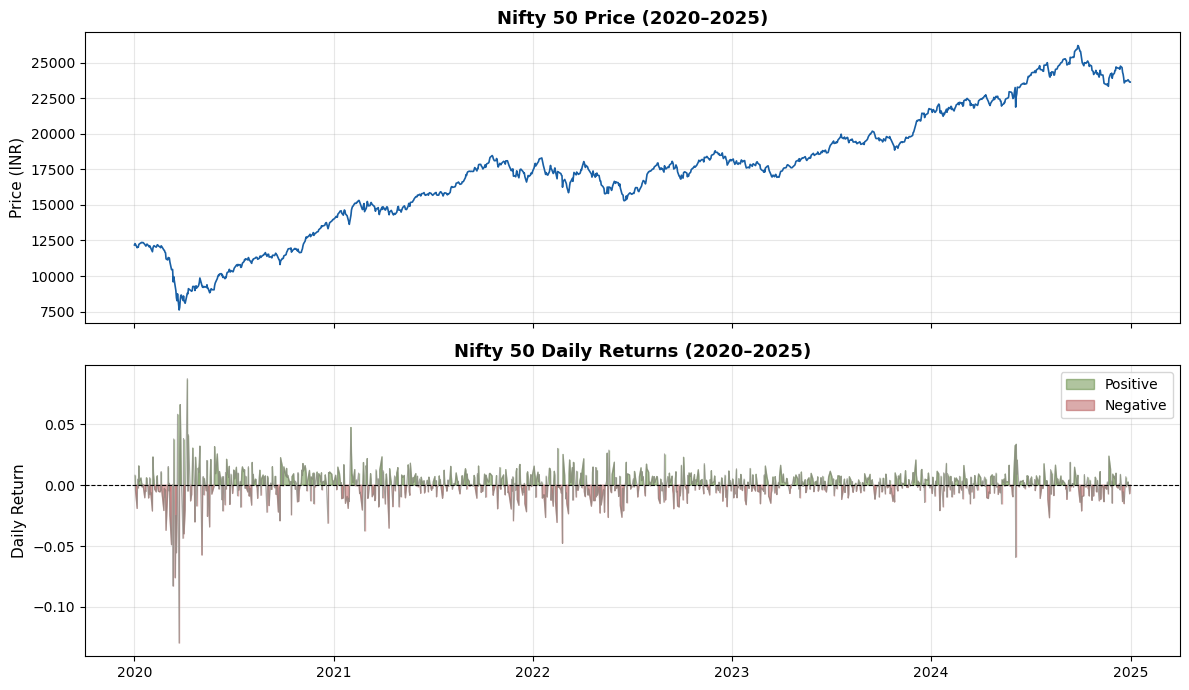

In [2]:
# --- Price vs Returns Plot ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top plot: Price series
ax1.plot(price, color="#185FA5", linewidth=1.2)
ax1.set_title("Nifty 50 Price (2020–2025)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Price (INR)", fontsize=11)
ax1.grid(True, alpha=0.3)

# Bottom plot: Returns series
ax2.plot(returns, color="#888780", linewidth=0.8, alpha=0.7)
ax2.fill_between(returns.index, returns, 0,
                 where=(returns >= 0), color="#3B6D11", alpha=0.4, label="Positive")
ax2.fill_between(returns.index, returns, 0,
                 where=(returns < 0),  color="#A32D2D", alpha=0.4, label="Negative")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Nifty 50 Daily Returns (2020–2025)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Daily Return", fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation: Price vs Returns

The two panels illustrate the concept of stationarity clearly:

- **Price series (non-stationary):** The mean continuously drifts upward from ~7,500
  to ~26,000. Shocks (like the COVID crash) are absorbed into a new, higher level.
  This series cannot be used directly in time series models.

- **Returns series (stationary):** The series bounces around a constant mean near zero
  throughout the entire period. Shocks are temporary — the series always reverts back.
  This is the correct input for time series modelling.

- **Volatility clustering:** The 2020 period shows dramatically larger swings than
  2022–2024. Large moves tend to be followed by more large moves — a phenomenon
  modelled by GARCH (covered later in this programme).

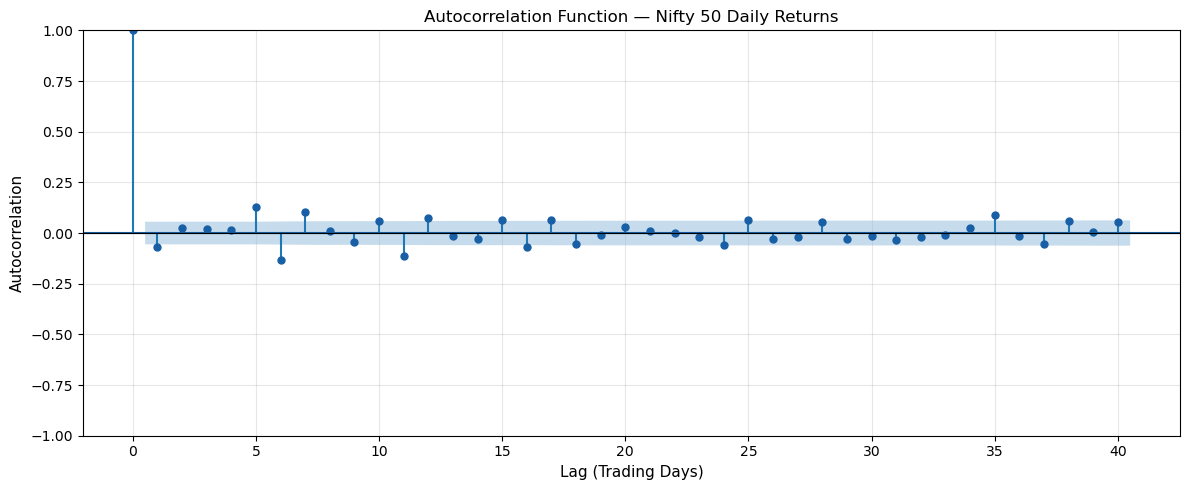

In [3]:
# --- ACF Plot ---

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(returns, lags=40, ax=ax, color="#185FA5",
         title="Autocorrelation Function — Nifty 50 Daily Returns")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lag (Trading Days)", fontsize=11)
ax.set_ylabel("Autocorrelation", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation: Autocorrelation Function (ACF)

The ACF plot tests whether past returns can predict future returns.

- **Lag 0** is always 1.0 by definition — a series is perfectly correlated with itself.
- **Lags 1–40** show autocorrelations clustered tightly around zero, with nearly all
  bars falling within the 95% confidence cone (blue shaded region).
- A handful of lags marginally touch the cone boundary — this is expected by chance
  alone when testing 40 lags simultaneously (roughly 2 out of 40 will cross at random).

**Conclusion:** Nifty 50 daily returns show no meaningful autocorrelation. Past returns
do not predict future returns at the daily frequency — consistent with the weak form
of the Efficient Market Hypothesis (EMH).

**Note:** Autocorrelation in raw returns is near-zero, but autocorrelation in *squared*
returns (a proxy for volatility) is significantly positive — meaning volatility clusters
over time. This is the foundation of GARCH modelling covered later in this programme.

In [4]:
# --- ADF Test ---

def run_adf(series, name):
    result = adfuller(series)
    adf_stat   = result[0]
    p_value    = result[1]
    crit_vals  = result[4]

    print(f"{'='*50}")
    print(f"ADF Test: {name}")
    print(f"{'='*50}")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"P-Value       : {p_value:.6f}")
    print()
    print("Critical Values:")
    for key, val in crit_vals.items():
        print(f"   {key} : {val:.4f}")
    print()

    if p_value < 0.05:
        print(f"Decision: STATIONARY ✓ (reject unit root)")
    else:
        print(f"Decision: NON-STATIONARY ✗ (fail to reject unit root)")
    print()

# Run on price series
run_adf(price, "Nifty 50 Price")

# Run on returns series
run_adf(returns, "Nifty 50 Daily Returns")

ADF Test: Nifty 50 Price
ADF Statistic : -0.4706
P-Value       : 0.897629

Critical Values:
   1% : -3.4357
   5% : -2.8639
   10% : -2.5680

Decision: NON-STATIONARY ✗ (fail to reject unit root)

ADF Test: Nifty 50 Daily Returns
ADF Statistic : -10.4801
P-Value       : 0.000000

Critical Values:
   1% : -3.4357
   5% : -2.8639
   10% : -2.5680

Decision: STATIONARY ✓ (reject unit root)



### ADF Test Results & Final Summary

| Series          | ADF Statistic | P-Value  | Decision          |
|-----------------|---------------|----------|-------------------|
| Nifty 50 Price  | -0.4706       | 0.8976   | Non-stationary ✗  |
| Nifty 50 Returns| -10.4801      | ~0.0000  | Stationary ✓      |

**Interpretation:**

1. **Price series (non-stationary):** The ADF statistic of −0.47 is far from the
   critical value of −2.86 at the 5% level. P-value of 0.897 means we cannot
   reject the unit root — the price series drifts permanently and cannot be
   modelled directly.

2. **Returns series (stationary):** The ADF statistic of −10.48 is far beyond
   even the 1% critical value of −3.43. P-value is essentially zero — returns
   are confirmed stationary with overwhelming confidence.

**Key takeaway:** Always test for stationarity before modelling any financial
time series. The standard transformation — taking percentage returns from prices
— is confirmed by the ADF test to produce a stationary series suitable for
ARIMA, VAR, and other time series models covered in the coming days.

### Partial Autocorrelation Function (PACF)

**PACF** measures the *direct* correlation between today's return and a lagged value,
after removing the influence of all intermediate lags.

- ACF at lag 2 includes the indirect effect through lag 1 — PACF removes that
- Where the PACF bars drop inside the shaded band and stay there → that is our **p** value for ARIMA

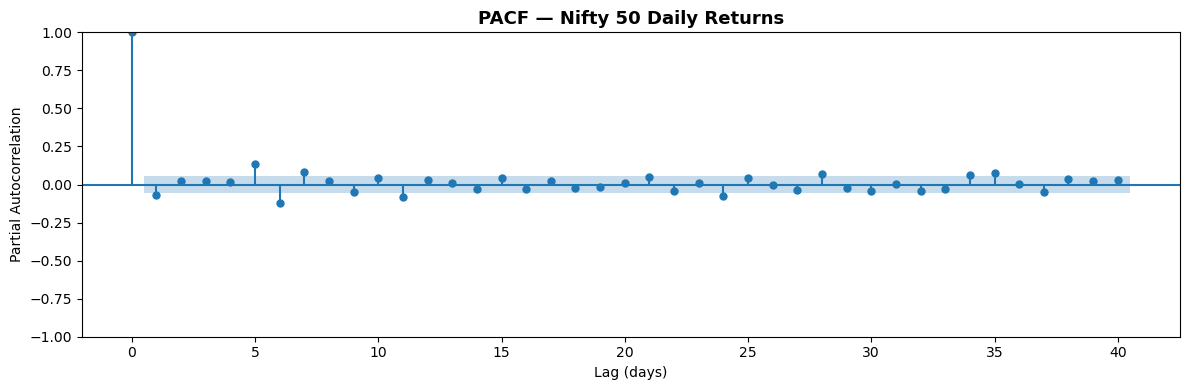

In [5]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(returns.dropna(), lags=40, ax=ax)
ax.set_title('PACF — Nifty 50 Daily Returns', fontsize=13, fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Partial Autocorrelation')
plt.tight_layout()
plt.show()

-------------------
## 2. ARIMA Forecasting

**ARIMA(p, d, q)** — AutoRegressive Integrated Moving Average — uses a series' own
past values and past forecast errors to predict future values.

For Nifty 50 daily returns:
- **p = 1** — PACF showed one significant lag → use yesterday's return as a predictor
- **d = 0** — ADF test confirmed returns are already stationary → no differencing needed
- **q = 1** — ACF showed one significant lag → use yesterday's forecast error as a predictor

We fit ARIMA(1,0,1) on Nifty returns and forecast the next 30 days.

In [6]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1,0,1) on Nifty returns
model = ARIMA(returns.dropna(), order=(1, 0, 1))
fitted = model.fit()
print(fitted.summary())

C:\Users\mulan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mulan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\mulan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  ^NSEI   No. Observations:                 1236
Model:                 ARIMA(1, 0, 1)   Log Likelihood                3712.353
Date:                Mon, 08 Jun 2026   AIC                          -7416.705
Time:                        20:21:51   BIC                          -7396.227
Sample:                             0   HQIC                         -7409.003
                               - 1236                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.709      0.087   -8.94e-05       0.001
ar.L1         -0.2580      0.134     -1.925      0.054      -0.521       0.005
ma.L1          0.1876      0.139      1.346      0.1

C:\Users\mulan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\mulan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


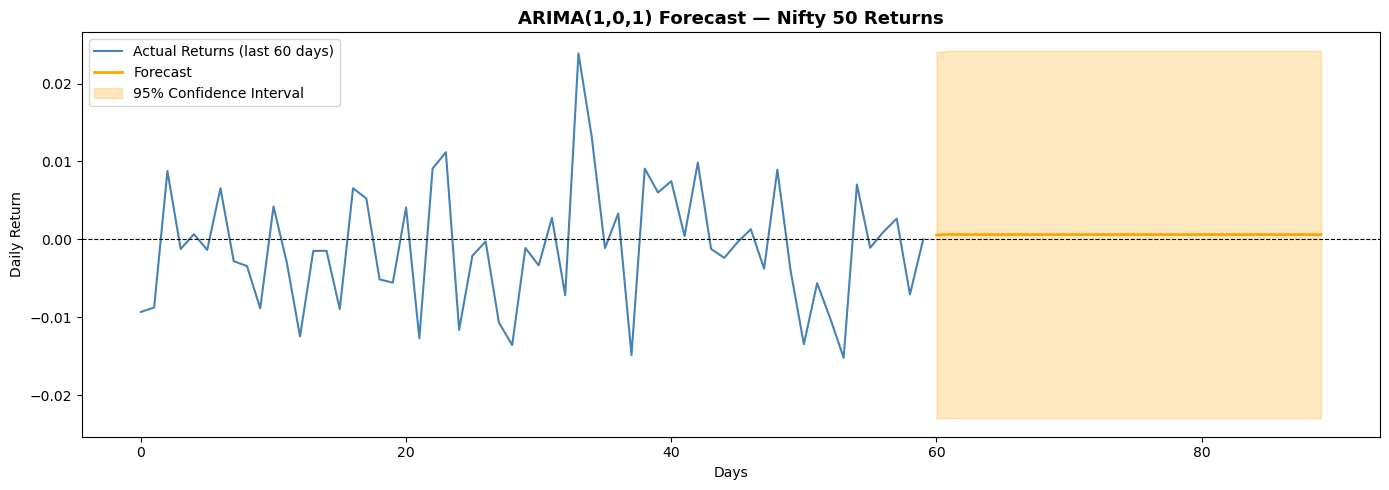

In [7]:
# Forecast next 30 days
forecast = fitted.get_forecast(steps=30)
forecast_mean = forecast.predicted_mean
conf_int      = forecast.conf_int()

plt.figure(figsize=(14, 5))
plt.plot(returns.dropna().values[-60:], label='Actual Returns (last 60 days)', color='steelblue')
plt.plot(range(60, 90), forecast_mean, label='Forecast', color='orange', linewidth=2)
plt.fill_between(range(60, 90), conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 alpha=0.25, color='orange', label='95% Confidence Interval')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('ARIMA(1,0,1) Forecast — Nifty 50 Returns', fontsize=13, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Daily Return')
plt.legend()
plt.tight_layout()
plt.show()

### Interpreting the ARIMA Forecast

**Forecast line:** The model predicts returns close to zero for the next 30 days.
This is expected — the AR and MA coefficients were statistically weak (p > 0.05),
meaning past returns carry very little information about future returns.

**Wide confidence interval:** The 95% CI spans approximately ±2.5%, reflecting the
true uncertainty in daily equity returns. Any single day could realistically fall
anywhere in this range.

**Key insight:** ARIMA forecasting near zero for Nifty returns is consistent with
the **Efficient Market Hypothesis** — in an efficient market, prices already reflect
all available information, so past returns should not strongly predict future returns.
The model is not failing — it is being statistically honest.

**Limitation:** ARIMA assumes constant volatility. The heteroskedasticity test
(p=0.00) showed volatility is not constant — calm and volatile periods cluster
together. A GARCH model would handle this better, but is beyond our current scope.

---
## 3. VAR Model — Nifty and Sensex

VAR (Vector Autoregression) extends ARIMA to model multiple time series simultaneously.
Each variable is modelled as a function of its own past values AND the past values of
all other variables in the system.

We use Nifty and Sensex daily returns together — both indices track the Indian equity
market, so they influence each other. VAR lets us model that mutual dependence.

In [8]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.vector_ar.var_model import VAR

# Download and squeeze to clean Series
nifty_r  = yf.download('^NSEI',  start='2020-01-01', end='2025-01-01')['Close'].squeeze().pct_change().dropna()
sensex_r = yf.download('^BSESN', start='2020-01-01', end='2025-01-01')['Close'].squeeze().pct_change().dropna()

# Combine into one DataFrame
df_var = pd.DataFrame({'Nifty': nifty_r, 'Sensex': sensex_r}).dropna()

print(df_var.shape)
print(df_var.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(1233, 2)
               Nifty    Sensex
Date                          
2020-01-03 -0.004523 -0.003892
2020-01-06 -0.019106 -0.019004
2020-01-07  0.004995  0.004741
2020-01-08 -0.002290 -0.001266
2020-01-09  0.015846  0.015547


### Fitting the VAR Model

We pass the full DataFrame into VAR and let it auto-select the best lag order
using AIC (Akaike Information Criterion). AIC balances model fit against complexity —
it penalises adding extra lags that don't meaningfully improve the model.

In [9]:
model = VAR(df_var)
results = model.fit(maxlags=5, ic='aic')
print(results.summary())

C:\Users\mulan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 08, Jun, 2026
Time:                     20:21:53
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -22.5526
Nobs:                     1228.00    HQIC:                  -22.6097
Log likelihood:           10440.6    FPE:                1.46472e-10
AIC:                     -22.6442    Det(Omega_mle):     1.43882e-10
--------------------------------------------------------------------
Results for equation Nifty
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.000527         0.000343            1.537           0.124
L1.Nifty         -0.902652         0.344026           -2.624           0.009
L1.Sensex         0.821950         0.338958            2.425           0.015

### Interpreting the VAR Output

The model selected 5 lags (VAR(5)) based on AIC, but only lag 1 is statistically
significant for both equations (p < 0.05).

For the Nifty equation:
- L1.Nifty coefficient = -0.90: yesterday's Nifty return negatively predicts today's
- L1.Sensex coefficient = +0.82: yesterday's Sensex return positively predicts today's
- These nearly cancel out, capturing short-term mean reversion between the two indices

Residual correlation of 0.997 confirms both indices are driven by almost identical
underlying market forces — the VAR captures their interaction but a shared macro
factor dominates both.

### Granger Causality Test

Granger causality tests whether past values of one variable help predict another,
beyond what that variable's own past already explains.

"Sensex Granger-causes Nifty" means: knowing yesterday's Sensex improves our
forecast of today's Nifty, over and above just knowing yesterday's Nifty alone.

Important: this is NOT economic causation. Both indices are driven by the same
underlying Indian market — Sensex doesn't cause Nifty to move. They move together
because of shared fundamentals. Granger causality is purely a forecasting concept.

In [10]:
# Test: does Sensex Granger-cause Nifty?
gc_test = results.test_causality('Nifty', 'Sensex', kind='f')
print(gc_test.summary())

Granger causality F-test. H_0: Sensex does not Granger-cause Nifty. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         1.430          2.218   0.210 (5, np.int64(2434))
---------------------------------------------------------


### Granger Causality Result

H0: Sensex does not Granger-cause Nifty
Result: Fail to reject H0 (F-statistic = 1.430, p-value = 0.210)

Conclusion: Past values of Sensex do not significantly improve forecasts of Nifty
beyond what Nifty's own history already provides.

This is expected — Nifty and Sensex track the same Indian equity market and carry
almost identical information. Once yesterday's Nifty is known, yesterday's Sensex
adds nothing new. High correlation (0.997) does not imply Granger causality.

Key distinction: Granger causality is a forecasting concept, not economic causation.